In [130]:
import pandas as pd

df = pd.read_csv("C:\\Users\\20245179\\OneDrive - TU Eindhoven\\Research Paper\\Combine sentiment intent\\Combined_Sentiment_Intent_all_data.csv")

c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Average similarity: 0.3049
Mean similarity: 0.305
Standard deviation: 0.177


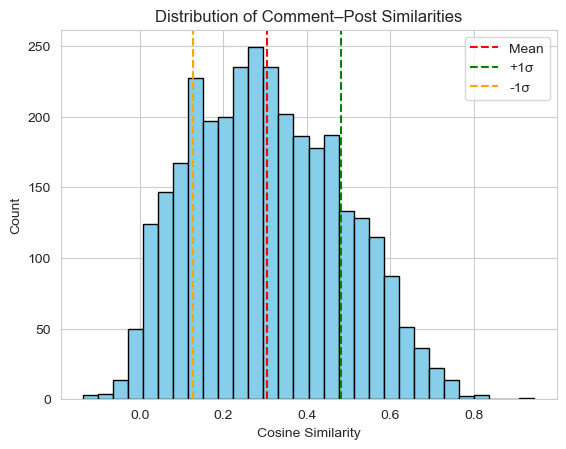

Similarity_Category
Average    2050
Low         582
High        565
Name: count, dtype: int64

In [132]:
# similarity of comments to its respective post


from sentence_transformers import SentenceTransformer, util
import numpy as np

# Encode posts from Affordability
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Encode posts and comments
post_embeddings = model.encode(df["Post"].tolist(), normalize_embeddings=False)
comment_embeddings = model.encode(df["Comment"].tolist(), normalize_embeddings=False)

# Compute cosine similarity per row (post-comment pair)
similarities = [
    util.cos_sim(post_embeddings[i], comment_embeddings[i]).item()
    for i in range(len(df))
]

df["Similarity"] = similarities
print(f"Average similarity: {np.mean(similarities):.4f}")

mean_sim = df["Similarity"].mean()
std_sim = df["Similarity"].std()

print(f"Mean similarity: {mean_sim:.3f}")
print(f"Standard deviation: {std_sim:.3f}")

import matplotlib.pyplot as plt

plt.hist(df["Similarity"], bins=30, color='skyblue', edgecolor='black')
plt.axvline(mean_sim, color='red', linestyle='--', label='Mean')
plt.axvline(mean_sim + 1* std_sim, color='green', linestyle='--', label='+1σ')
plt.axvline(mean_sim - 1* std_sim, color='orange', linestyle='--', label='-1σ')
plt.legend()
plt.title('Distribution of Comment–Post Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()


def categorize_similarity(x, mean, std):
    if x > mean + 1* std:
        return "High"
    elif x < mean - 1* std:
        return "Low"
    else:
        return "Average"

df["Similarity_Category"] = df["Similarity"].apply(lambda x: categorize_similarity(x, mean_sim, std_sim))
df["Similarity_Category"].value_counts()


In [96]:
df

,Post,Comment,Comments_time,Sentiment over comment from models,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,roberta_prob_Criticism,roberta_prob_Inquiry,roberta_prob_Statement,debertaV3_prob_Appreciation,debertaV3_prob_Criticism,debertaV3_prob_Inquiry,debertaV3_prob_Statement,Similarity,Similarity_Category
0,De zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02T22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,0.010230,0.969726,0.009778,0.006892,0.007853,0.976574,0.008681,0.747707,High
1,IN ACTI-UM | Onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21T15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,0.675144,0.260916,0.049653,0.025655,0.793703,0.133921,0.046721,0.276356,Average
2,IN ACTI-UM | Onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21T10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,0.009202,0.012336,0.968804,0.023275,0.022295,0.892222,0.062208,0.226165,Average
3,Een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01T15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,0.009435,0.008839,0.011158,0.970569,0.018176,0.098000,0.020942,0.862882,0.304114,Average
4,Een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31T11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,0.009971,0.969894,0.009972,0.010163,0.008846,0.971164,0.010590,0.009401,0.555419,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,Vorige week zijn de laatste huizen van 't Getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30T10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,0.010446,0.011022,0.967815,0.046441,0.468294,0.384625,0.100641,0.318798,Average
3193,Op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22T12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,0.009886,0.969729,0.010232,0.007499,0.009257,0.973253,0.009991,0.351911,Average
3194,Op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21T15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,0.043500,0.882523,0.059211,0.007726,0.971546,0.011449,0.009280,0.205661,Average
3195,Op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19T10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,0.009513,0.970988,0.010042,0.007704,0.008165,0.974475,0.009655,0.615284,High


In [97]:
# assuming your DataFrame is called df
intents = ['Appreciation', 'Criticism', 'Inquiry', 'Statement']

for intent in intents:
    df[f"avg_prob_{intent}"] = df[[f"GRO_NLP_prob_{intent}",
                                   f"roberta_prob_{intent}",
                                   f"debertaV3_prob_{intent}"]].mean(axis=1)
    
#create new column avg_prob_Forward and fill with 1 where final_label is Forward else 0
df["avg_prob_Forward"] = df["final_label_three_models_final"].apply(lambda x: 1 if x == "Forward" else 0)

features = [
    "avg_prob_Appreciation",
    "avg_prob_Criticism",
    "avg_prob_Inquiry",
    "avg_prob_Statement",
    "avg_prob_Forward",
    "Similarity",
    "Sentiment over comment from models",
    
]

X = df[features].copy()


In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [99]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


scores = []
for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    scores.append(silhouette_score(X_scaled, km.labels_))
pd.DataFrame({"k": range(2, 20), "silhouette": scores})

c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmean

c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmean

,k,silhouette
0,2,0.280775
1,3,0.318717
2,4,0.323555
3,5,0.294716
4,6,0.394826
5,7,0.363597
6,8,0.383857
7,9,0.391386
8,10,0.388937
9,11,0.387484


In [100]:

k = 6 # pick based on elbow/ silhouette
kmeans = KMeans(n_clusters=k, random_state=42)
df["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)


c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(


In [101]:
cluster_summary = (
    df.groupby("Cluster_KMeans")[features]
    .mean()
    .sort_values("avg_prob_Criticism", ascending=False)
)
print(cluster_summary)


                avg_prob_Appreciation  avg_prob_Criticism  avg_prob_Inquiry  \
Cluster_KMeans                                                                
1                            0.020038            0.805592          0.085660   
0                            0.111116            0.180633          0.084558   
3                            0.019972            0.089576          0.080606   
5                            0.018181            0.063944          0.858470   
4                            0.023629            0.060959          0.056231   
2                            0.799209            0.046505          0.032126   

                avg_prob_Statement  avg_prob_Forward  Similarity  \
Cluster_KMeans                                                     
1                         0.088710          0.023707    0.369832   
0                         0.623693          0.002320    0.359253   
3                         0.809845          0.000000    0.211348   
5                         0

In [102]:
df

,Post,Comment,Comments_time,Sentiment over comment from models,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,...,debertaV3_prob_Inquiry,debertaV3_prob_Statement,Similarity,Similarity_Category,avg_prob_Appreciation,avg_prob_Criticism,avg_prob_Inquiry,avg_prob_Statement,avg_prob_Forward,Cluster_KMeans
0,De zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02T22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,...,0.976574,0.008681,0.747707,High,0.009201,0.009817,0.971441,0.009540,0,5
1,IN ACTI-UM | Onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21T15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,...,0.133921,0.046721,0.276356,Average,0.022426,0.497858,0.382355,0.097361,0,1
2,IN ACTI-UM | Onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21T10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,...,0.892222,0.062208,0.226165,Average,0.015563,0.024824,0.347871,0.611742,0,3
3,Een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01T15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,0.009435,...,0.020942,0.862882,0.304114,Average,0.012880,0.040373,0.018024,0.928723,0,3
4,Een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31T11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,0.009971,...,0.010590,0.009401,0.555419,High,0.022069,0.713980,0.018272,0.245680,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,Vorige week zijn de laatste huizen van 't Getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30T10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,...,0.384625,0.100641,0.318798,Average,0.032528,0.175175,0.299785,0.492512,0,3
3193,Op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22T12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,...,0.973253,0.009991,0.351911,Average,0.009402,0.009871,0.970402,0.010325,0,5
3194,Op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21T15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,...,0.011449,0.009280,0.205661,Average,0.016480,0.574263,0.316963,0.092293,1,4
3195,Op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19T10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,...,0.974475,0.009655,0.615284,High,0.009550,0.009630,0.970747,0.010073,0,5


ValueError: invalid literal for int() with base 10: '$\\mathdefault{0}$'

ValueError: invalid literal for int() with base 10: '$\\mathdefault{0}$'

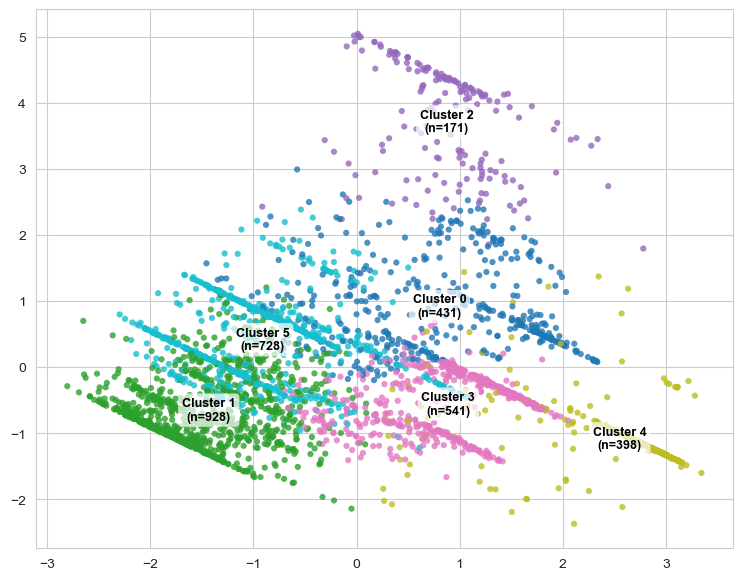

In [103]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# --- 1) Run PCA (already scaled) ---
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

df["PC1"] = X_2d[:, 0]
df["PC2"] = X_2d[:, 1]

# --- 2) Plot setup ---
plt.figure(figsize=(9, 7))

# Scatter plot for clusters
scatter = plt.scatter(
    df["PC1"],
    df["PC2"],
    c=df["Cluster_KMeans"],
    cmap="tab10",
    s=20,
    alpha=0.8,
    edgecolors="none"
)

# --- 3) Add cluster centroids with labels ---
for cluster_id, group in df.groupby("Cluster_KMeans"):
    # Compute cluster centroid (mean position)
    cx, cy = group["PC1"].mean(), group["PC2"].mean()

    # Add label text
    plt.text(
        cx, cy,
        f"Cluster {cluster_id}\n(n={len(group)})",
        ha="center", va="center",
        fontsize=9,
        weight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
    )

# --- 4) Add legend and colorbar ---
# Unique cluster IDs and colors
handles, labels_unique = scatter.legend_elements(prop="colors", alpha=0.6)
plt.legend(handles, [f"Cluster {int(label)}" for label in labels_unique],
           title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')

# --- 5) Titles and axis labels ---
plt.title("PCA Projection of Clusters\n(Intent Probabilities + Similarity + Sentiment)", fontsize=12, pad=15)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.tight_layout()
plt.show()


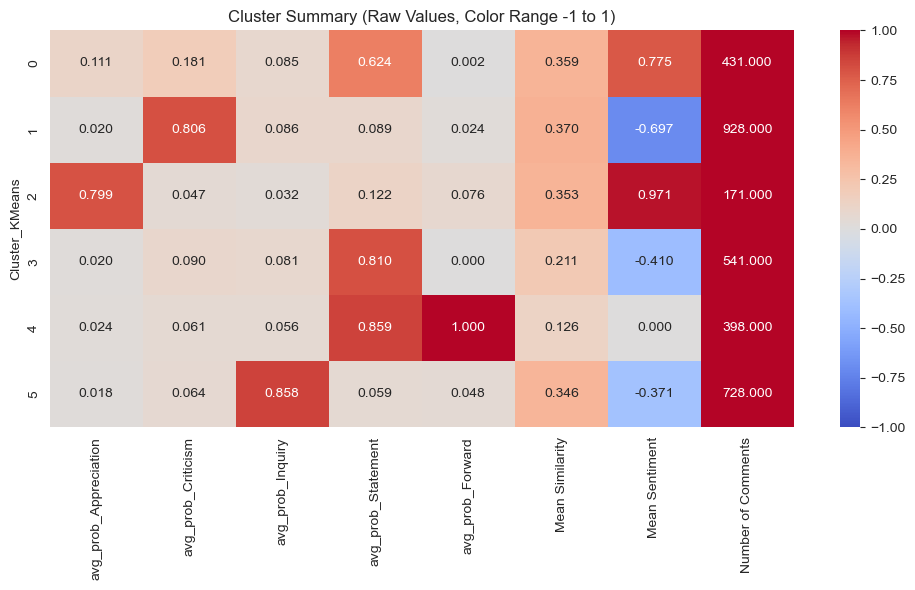

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# df = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Clustering\Probabilties\Clustered_Comments_Probabilities_KMeans.csv")
# rename sentiment over comments from models to Sentiment
df.rename(columns={'Sentiment over comment from models': 'Sentiment'}, inplace=True)

# 1️⃣ Raw cluster summary (unchanged)
cluster_summary = df.groupby('Cluster_KMeans')[[
    'avg_prob_Appreciation',
    'avg_prob_Criticism',
    'avg_prob_Inquiry',
    'avg_prob_Statement',
    'avg_prob_Forward',
    'Similarity',
    'Sentiment'
]].mean().round(3)

cluster_summary["Number of Comments"] = df.groupby('Cluster_KMeans').size()
cluster_summary.rename(columns={"Similarity": "Mean Similarity"}, inplace=True)
cluster_summary.rename(columns={"Sentiment": "Mean Sentiment"}, inplace=True)
# 2️⃣ Fixed color range using raw values
vmin, vmax = -1, 1   # assuming sentiment can go down to -1; others live in [0,1]

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_summary,
    cmap="coolwarm",      # diverging: blue (-1) → white (0) → red (1)
    vmin=vmin,
    vmax=vmax,
    annot=True,           # annotate with raw values
    fmt=".3f"
)
plt.title("Cluster Summary (Raw Values, Color Range -1 to 1)")
plt.tight_layout()
plt.show()


In [37]:
df

,Post,Comment,Comments_time,Sentiment,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,...,post_length,num_unique_words,energ,isolat,warmt,zonne,duurz,renov,num_comments_y,num_comments
0,de zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02T22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,...,65,48,0,0,0,1,0,0,1,1
1,in acti-um | onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21T15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,...,61,47,0,0,0,0,1,0,2,2
2,in acti-um | onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21T10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,...,61,47,0,0,0,0,1,0,2,2
3,een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01T15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,0.009435,...,51,46,1,0,0,0,0,0,2,2
4,een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31T11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,0.009971,...,51,46,1,0,0,0,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,vorige week zijn de laatste huizen van 't getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30T10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,...,46,37,0,0,0,0,1,0,3,3
3193,op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22T12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,...,62,51,0,0,0,0,0,1,4,4
3194,op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21T15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,...,62,51,0,0,0,0,0,1,4,4
3195,op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19T10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,...,62,51,0,0,0,0,0,1,4,4



CLUSTER GROWTH INDICES (Q1 2018 to Q1 2023)
Growth Index Calculation Methods:
• Total Growth Index: Final Value ÷ Initial Value
• Avg Quarterly Growth Index: (Total Growth Index)^(1/number_of_quarters)
  - Index > 1.0 = Growth, Index < 1.0 = Decline, Index = 1.0 = No change
----------------------------------------------------------------------------------------------------
Constructive Criticism    |    4: 100 | Total Index:  25.00 | Avg Q Index:  1.175
Content Sharing           |    8:  24 | Total Index:   3.00 | Avg Q Index:  1.056
Information Seeking       |   11:  76 | Total Index:   6.91 | Avg Q Index:  1.101
Irrelevant Statements     |    7:  45 | Total Index:   6.43 | Avg Q Index:  1.098
Positive Feedback         |    4:  16 | Total Index:   4.00 | Avg Q Index:  1.072
Relevant Comments         |    7:  29 | Total Index:   4.14 | Avg Q Index:  1.074


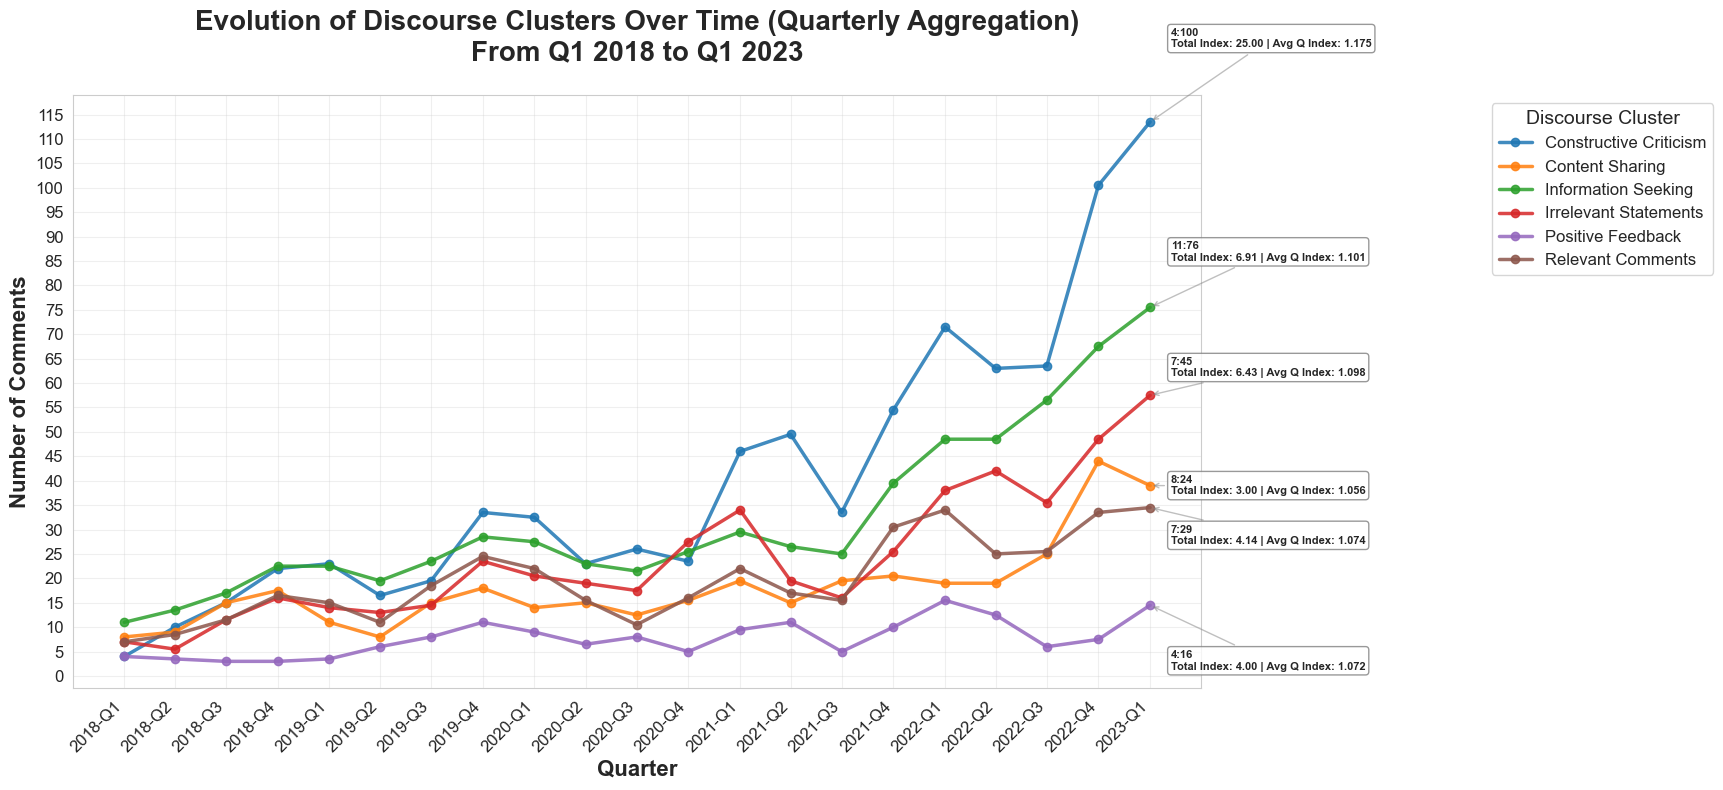

In [10]:
# Smoothed timeline visualization aggregated by quarter (Q1 2018 to Q1 2023)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import MultipleLocator
import numpy as np

# Load data
df = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Clustering\Probabilties\Clustered_Comments_Probabilities_KMeans.csv")

# Ensure datetime format
df["Comments_time"] = pd.to_datetime(df["Comments_time"])

# Filter data from Q1 2018 to Q1 2023
start_date = datetime(2018, 1, 1)
end_date = datetime(2023, 3, 31)
df_filtered = df[(df["Comments_time"] >= start_date) & (df["Comments_time"] <= end_date)].copy()

# Group by quarter
df_filtered["quarter"] = df_filtered["Comments_time"].dt.to_period("Q").dt.to_timestamp()

# Count clusters per quarter
cluster_time_quarterly = df_filtered.groupby(["quarter", "Cluster_KMeans"]).size().reset_index(name="count")

# Pivot for plotting
pivot_df_quarterly = cluster_time_quarterly.pivot(index="quarter", columns="Cluster_KMeans", values="count").fillna(0)

# Apply moving average smoothing but preserve first and last points
smoothed_quarterly = pivot_df_quarterly.rolling(window=2, center=False, min_periods=1).mean()

# Cluster name mapping
cluster_names = {
    1: 'Constructive Criticism',
    5: 'Information Seeking',
    3: 'Irrelevant Statements',
    4: 'Content Sharing',
    0: 'Relevant Comments',
    2: 'Positive Feedback', 
}

# Calculate growth indices for each cluster using SMOOTHED data
def calculate_growth_indices(data, raw_data):
    """
    Calculate growth indices for each cluster:
    - Total Growth Index: final_value / initial_value
    - Average Quarterly Growth Index: (final_value / initial_value)^(1/number_of_quarters)
    """
    growth_stats = {}
    for cluster in data.columns:
        # Use smoothed values for display
        smoothed_values = data[cluster].values
        first_smoothed = smoothed_values[0]
        last_smoothed = smoothed_values[-1]
        
        # Use raw values for growth calculation (more meaningful)
        raw_values = raw_data[cluster].values
        first_raw = raw_values[0] if raw_values[0] > 0 else 1  # Avoid division by zero
        last_raw = raw_values[-1]
        
        # Total growth index (ratio of final to initial)
        total_growth_index = last_raw / first_raw
        
        # Number of quarters for average calculation
        num_quarters = len(raw_values) - 1  # Number of transitions
        
        # Average quarterly growth index (geometric mean)
        avg_quarterly_growth_index = total_growth_index ** (1 / num_quarters) if num_quarters > 0 else 1.0
        
        growth_stats[cluster] = {
            'total_growth_index': total_growth_index,
            'avg_quarterly_growth_index': avg_quarterly_growth_index,
            'first_raw': first_raw,
            'last_raw': last_raw,
            'first_smoothed': first_smoothed,
            'last_smoothed': last_smoothed,
            'cluster_name': cluster_names.get(cluster, f"Cluster {cluster}")
        }
    
    return growth_stats

# Calculate growth statistics
growth_stats = calculate_growth_indices(smoothed_quarterly, pivot_df_quarterly)

# Create smoothed visualization
plt.figure(figsize=(18, 8))
sns.set_style("whitegrid")

# Sort clusters by their names for ordered legend
clusters_sorted_by_name = sorted(pivot_df_quarterly.columns, key=lambda x: cluster_names.get(x, f"Cluster {x}"))

for cluster in clusters_sorted_by_name:
    plt.plot(
        pivot_df_quarterly.index,
        smoothed_quarterly[cluster],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=cluster_names.get(cluster, f"Cluster {cluster}"),
        alpha=0.85
    )

# Add growth indices at the end of each line with offset positioning to avoid overlap
last_x = pivot_df_quarterly.index[-1]

# Sort clusters by their final y-values to position annotations without overlap
cluster_end_values = [(cluster, smoothed_quarterly[cluster].iloc[-1]) for cluster in clusters_sorted_by_name]
cluster_end_values.sort(key=lambda x: x[1])  # Sort by end value

# Define vertical offsets to prevent overlap
vertical_offsets = [-40, -20, 0, 20, 40, 60]  # Adjust these values as needed

for i, (cluster, last_y) in enumerate(cluster_end_values):
    total_growth_idx = growth_stats[cluster]['total_growth_index']
    avg_growth_idx = growth_stats[cluster]['avg_quarterly_growth_index']
    start_raw = growth_stats[cluster]['first_raw']
    end_raw = growth_stats[cluster]['last_raw']
    
    # Format growth text with simplified start:end format
    growth_text = f"{start_raw:.0f}:{end_raw:.0f}\nTotal Index: {total_growth_idx:.2f} | Avg Q Index: {avg_growth_idx:.3f}"
    
    # Use different vertical offsets for each cluster
    vertical_offset = vertical_offsets[i] if i < len(vertical_offsets) else 60 + (i - len(vertical_offsets)) * 20
    
    plt.annotate(
        growth_text,
        xy=(last_x, last_y),
        xytext=(15, vertical_offset),  # 15 points right, varying vertical offset
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        verticalalignment='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5)  # Add small arrow to connect to line
    )

plt.title("Evolution of Discourse Clusters Over Time (Quarterly Aggregation)\nFrom Q1 2018 to Q1 2023", 
          fontsize=20, pad=25, fontweight='bold')
plt.xlabel("Quarter", fontsize=16, fontweight='bold')
plt.ylabel("Number of Comments", fontsize=16, fontweight='bold')

plt.legend(title="Discourse Cluster", title_fontsize=14, fontsize=12,
           bbox_to_anchor=(1.25, 1), loc='upper left')

quarter_labels = [f"{date.year}-Q{((date.month-1)//3)+1}" 
                  for date in pivot_df_quarterly.index]

plt.xticks(pivot_df_quarterly.index, quarter_labels,
           rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Print growth statistics summary with detailed calculation explanation
print("\n" + "="*100)
print("CLUSTER GROWTH INDICES (Q1 2018 to Q1 2023)")
print("="*100)
print("Growth Index Calculation Methods:")
print("• Total Growth Index: Final Value ÷ Initial Value")
print("• Avg Quarterly Growth Index: (Total Growth Index)^(1/number_of_quarters)")
print("  - Index > 1.0 = Growth, Index < 1.0 = Decline, Index = 1.0 = No change")
print("-" * 100)

for cluster in clusters_sorted_by_name:
    stats = growth_stats[cluster]
    print(f"{stats['cluster_name']:25} | {stats['first_raw']:4.0f}:{stats['last_raw']:4.0f} | "
          f"Total Index: {stats['total_growth_index']:6.2f} | Avg Q Index: {stats['avg_quarterly_growth_index']:6.3f}")

plt.show()

In [53]:
df = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Clustering\Probabilties\Clustered_Comments_Probabilities_KMeans.csv")


In [54]:
df

,Post,Comment,Comments_time,Sentiment over comment from models,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,...,post_length,num_unique_words,energ,isolat,warmt,zonne,duurz,renov,num_comments_y,num_comments
0,de zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02T22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,...,65,48,0,0,0,1,0,0,1,1
1,in acti-um | onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21T15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,...,61,47,0,0,0,0,1,0,2,2
2,in acti-um | onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21T10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,...,61,47,0,0,0,0,1,0,2,2
3,een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01T15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,0.009435,...,51,46,1,0,0,0,0,0,2,2
4,een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31T11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,0.009971,...,51,46,1,0,0,0,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,vorige week zijn de laatste huizen van 't getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30T10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,...,46,37,0,0,0,0,1,0,3,3
3193,op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22T12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,...,62,51,0,0,0,0,0,1,4,4
3194,op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21T15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,...,62,51,0,0,0,0,0,1,4,4
3195,op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19T10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,...,62,51,0,0,0,0,0,1,4,4


In [61]:
# Create one-hot encoding for Similarity_Category
similarity_dummies = pd.get_dummies(df['Similarity_Category'], prefix='Similarity')

# Combine with other features (excluding the original numeric Similarity column)
features_numeric = [
    "avg_prob_Appreciation",
    "avg_prob_Criticism",
    "avg_prob_Inquiry",
    "avg_prob_Statement",
    "avg_prob_Forward",
    "Sentiment over comment from models",
]

# Create feature matrix with numeric features + one-hot encoded similarity
X_numeric = df[features_numeric].copy()
X = pd.concat([X_numeric, similarity_dummies], axis=1)

print("Features being used for clustering:")
print(X.columns.tolist())
print(f"\nShape: {X.shape}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


scores = []
for k in range(2, 20):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    scores.append(silhouette_score(X_scaled, km.labels_))
pd.DataFrame({"k": range(2, 20), "silhouette": scores})

k = 12 # pick based on elbow/ silhouette
kmeans = KMeans(n_clusters=k, random_state=42)
df["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

Features being used for clustering:
['avg_prob_Appreciation', 'avg_prob_Criticism', 'avg_prob_Inquiry', 'avg_prob_Statement', 'avg_prob_Forward', 'Sentiment over comment from models', 'Similarity_Average', 'Similarity_High', 'Similarity_Low']

Shape: (3197, 9)


c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=13.
  warnings.warn(
c:\Users\20245179\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmean

In [58]:
df

,Post,Comment,Comments_time,Sentiment over comment from models,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,...,post_length,num_unique_words,energ,isolat,warmt,zonne,duurz,renov,num_comments_y,num_comments
0,de zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02T22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,...,65,48,0,0,0,1,0,0,1,1
1,in acti-um | onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21T15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,...,61,47,0,0,0,0,1,0,2,2
2,in acti-um | onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21T10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,...,61,47,0,0,0,0,1,0,2,2
3,een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01T15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,0.009435,...,51,46,1,0,0,0,0,0,2,2
4,een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31T11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,0.009971,...,51,46,1,0,0,0,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,vorige week zijn de laatste huizen van 't getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30T10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,...,46,37,0,0,0,0,1,0,3,3
3193,op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22T12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,...,62,51,0,0,0,0,0,1,4,4
3194,op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21T15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,...,62,51,0,0,0,0,0,1,4,4
3195,op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19T10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,...,62,51,0,0,0,0,0,1,4,4


Cluster Summary with Similarity Categories:
                avg_prob_Appreciation  avg_prob_Criticism  avg_prob_Inquiry  \
Cluster_KMeans                                                                
0                               0.158               0.149             0.064   
1                               0.016               0.093             0.831   
2                               0.034               0.088             0.086   
3                               0.016               0.046             0.030   
4                               0.040               0.080             0.582   
5                               0.832               0.040             0.028   
6                               0.022               0.820             0.079   
7                               0.036               0.260             0.065   
8                               0.023               0.053             0.863   
9                               0.019               0.064             0.833   
10      

Cluster Summary with Similarity Categories:
                avg_prob_Appreciation  avg_prob_Criticism  avg_prob_Inquiry  \
Cluster_KMeans                                                                
0                               0.158               0.149             0.064   
1                               0.016               0.093             0.831   
2                               0.034               0.088             0.086   
3                               0.016               0.046             0.030   
4                               0.040               0.080             0.582   
5                               0.832               0.040             0.028   
6                               0.022               0.820             0.079   
7                               0.036               0.260             0.065   
8                               0.023               0.053             0.863   
9                               0.019               0.064             0.833   
10      

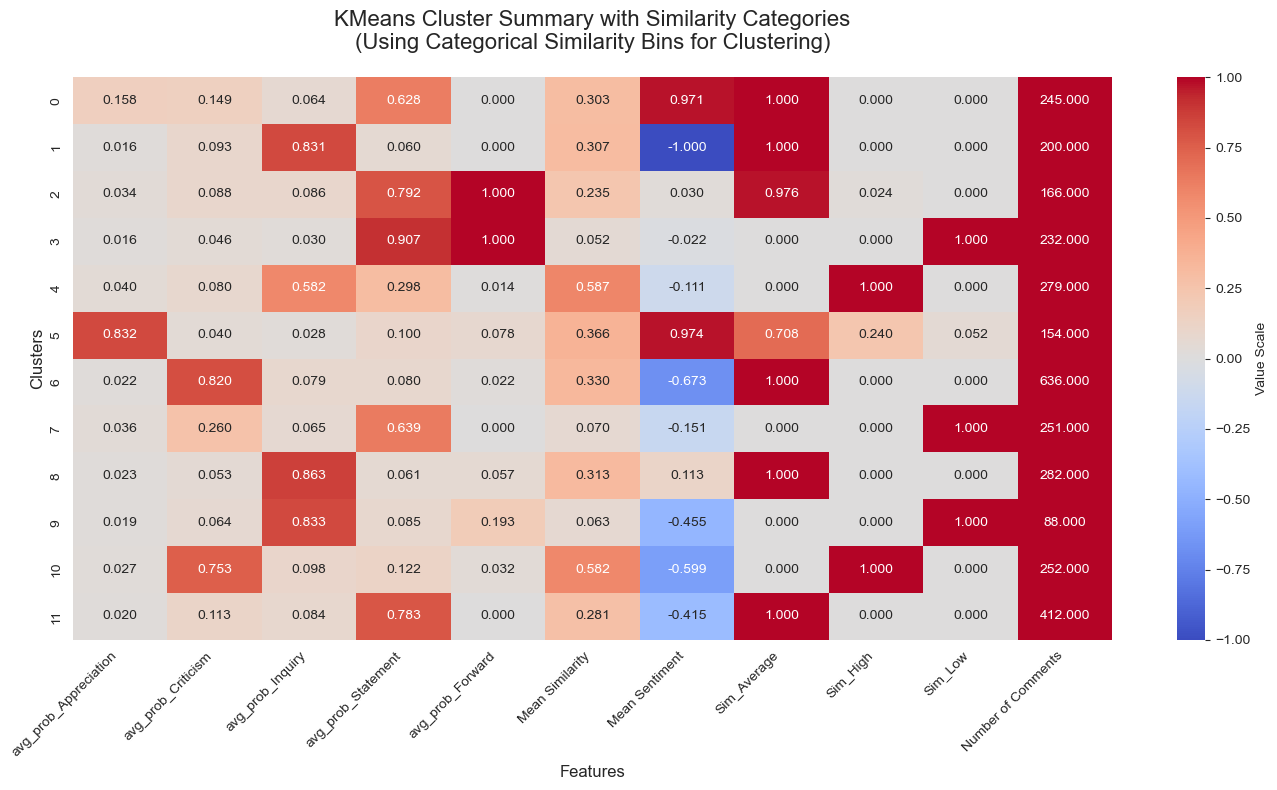

In [62]:
# Create cluster summary with new features including similarity categories
cluster_summary = df.groupby('Cluster_KMeans')[[
    'avg_prob_Appreciation',
    'avg_prob_Criticism',
    'avg_prob_Inquiry',
    'avg_prob_Statement',
    'avg_prob_Forward',
    'Similarity',  # Keep original similarity for reference
    'Sentiment over comment from models'
]].mean().round(3)

# Add similarity category proportions for each cluster
similarity_category_props = df.groupby('Cluster_KMeans')['Similarity_Category'].value_counts(normalize=True).unstack(fill_value=0)
similarity_category_props.columns = [f'Sim_{col}' for col in similarity_category_props.columns]

# Combine the summaries
cluster_summary_combined = pd.concat([cluster_summary, similarity_category_props], axis=1)

cluster_summary_combined["Number of Comments"] = df.groupby('Cluster_KMeans').size()

# Rename columns for better display
cluster_summary_combined.rename(columns={
    "Similarity": "Mean Similarity",
    "Sentiment over comment from models": "Mean Sentiment"
}, inplace=True)

print("Cluster Summary with Similarity Categories:")
print(cluster_summary_combined)

# Create heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Fixed color range using raw values
vmin, vmax = -1, 1   # assuming sentiment can go down to -1; others live in [0,1]

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_summary_combined,
    cmap="coolwarm",      # diverging: blue (-1) → white (0) → red (1)
    vmin=vmin,
    vmax=vmax,
    annot=True,           # annotate with raw values
    fmt=".3f",
    cbar_kws={'label': 'Value Scale'}
)
plt.title("KMeans Cluster Summary with Similarity Categories\n(Using Categorical Similarity Bins for Clustering)", 
          fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Clusters", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# corelate comment distribution to the posts features

In [106]:
df.to_csv("C:\\Users\\20245179\\OneDrive - TU Eindhoven\\Research Paper\\Clustering\\Probabilties\\Clustered_Comments_Probabilities_KMeans.csv", index=False)

In [122]:
# posts features to be created: length, number of comments, topics covered,  nu_words
import pandas as pd

df1 = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Data\final_data_with_author_names.csv")

posts_df = df.copy()   # your original posts dataframe





#number pf comments per post
comments_per_post = posts_df.groupby('Post').size().reset_index(name='num_comments')


# post length
posts_df['post_length'] = posts_df['Post'].apply(lambda x: len(str(x).split()))
bins = [0, 50, 150, 300, np.inf]          # adjust as you like
labels = ["tweet (<50)", "short (50-150)", "abstract (150-300)", "long (>300)"]

posts_df["length_category"] = pd.cut(posts_df["post_length"], bins=bins, labels=labels,
                               right=True, include_lowest=True)

# number of unique words in posts
posts_df['num_unique_words'] = posts_df['Post'].apply(lambda x: len(set(str(x).split())))
posts_df["num_hashtags"] = posts_df["Post"].str.count(r"#\w+")
posts_df["has_question"] = posts_df["Post"].str.contains(r"\?", regex=True).astype(int)
posts_df["contains_url"] = posts_df["Post"].str.contains(r"http\S+", regex=True).astype(int)
%pip install textstat
import textstat
posts_df["readability"] = posts_df["Post"].apply(lambda x: textstat.flesch_reading_ease(x))

# sustainability_keywords = ["energ", "isolat", "warmt", "zonne", "duurz", "renov"]


# Ensure 'post' column is lowercase and handles missing values
posts_df['Post'] = posts_df['Post'].fillna('')

# # Create a binary column for each keyword
# for kw in sustainability_keywords:
#     posts_df[kw] = posts_df['Post'].apply(lambda x: int(kw in x))

# merge author name from df2 on Post

df2 = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Data\final_data_with_author_names.csv")
df2 = df2[['text_ha', 'author_name']]

# Make sure both columns are lowercase strings
posts_df['Post'] = posts_df['Post'].astype(str).str.lower()
df2['text_ha'] = df2['text_ha'].astype(str).str.lower()

# Drop duplicates in df2 to prevent row duplication
df2_unique = df2.drop_duplicates(subset='text_ha')

# Merge only author_name into posts_df (row count will stay the same)
posts_df = posts_df.merge(
    df2_unique[['text_ha', 'author_name']],
    left_on='Post',
    right_on='text_ha',
    how='left'
)




Note: you may need to restart the kernel to use updated packages.


In [123]:
posts_df

,Post,Comment,Comments_time,Sentiment,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,...,PC2,post_length,length_category,num_unique_words,num_hashtags,has_question,contains_url,readability,text_ha,author_name
0,de zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02 22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,...,0.732400,65,short (50-150),49,0,0,0,67.996635,de zonnepanelen op het dak van ons kantoor doe...,WormerWonen
1,in acti-um | onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21 15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,...,0.084632,61,short (50-150),47,1,0,0,54.840000,in acti-um | onze vakmannen vervangen bij iede...,Actium
2,in acti-um | onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21 10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,...,-0.716585,61,short (50-150),47,1,0,0,54.840000,in acti-um | onze vakmannen vervangen bij iede...,Actium
3,een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01 15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,0.009435,...,-0.921441,51,short (50-150),48,0,1,1,68.752588,een hoog energieverbruik is slecht voor het mi...,NaN
4,een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31 11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,0.009971,...,0.152901,51,short (50-150),48,0,1,1,68.752588,een hoog energieverbruik is slecht voor het mi...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,vorige week zijn de laatste huizen van 't getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30 10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,...,0.173767,46,tweet (<50),37,0,0,0,71.728188,vorige week zijn de laatste huizen van 't getf...,De Woonplaats
3193,op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22 12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,...,0.818739,62,short (50-150),53,0,0,0,76.269247,op de 1e verdieping van het oude schoolgebouw ...,Woongoed Zeist
3194,op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21 15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,...,-0.818682,62,short (50-150),53,0,0,0,76.269247,op de 1e verdieping van het oude schoolgebouw ...,Woongoed Zeist
3195,op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19 10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,...,0.513431,62,short (50-150),53,0,0,0,76.269247,op de 1e verdieping van het oude schoolgebouw ...,Woongoed Zeist


In [127]:
pd.crosstab(posts_df["length_category"], posts_df["Cluster_KMeans"])

Cluster_KMeans,0,1,2,3,4,5
length_category,,,,,,
tweet (<50),125,242,61,136,113,187
short (50-150),270,618,101,376,256,477
abstract (150-300),36,68,9,29,29,62
long (>300),0,0,0,0,0,2


In [129]:
# count the number of unique posts per length category
unique_posts_per_length = posts_df.groupby("length_category")["Post"].nunique().reset_index()
unique_posts_per_length.columns = ["length_category", "num_unique_posts"]
print(unique_posts_per_length)


      length_category  num_unique_posts
0         tweet (<50)               253
1      short (50-150)               474
2  abstract (150-300)                63
3         long (>300)                 2


C:\Users\20245179\AppData\Local\Temp\ipykernel_1920\1786273567.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unique_posts_per_length = posts_df.groupby("length_category")["Post"].nunique().reset_index()


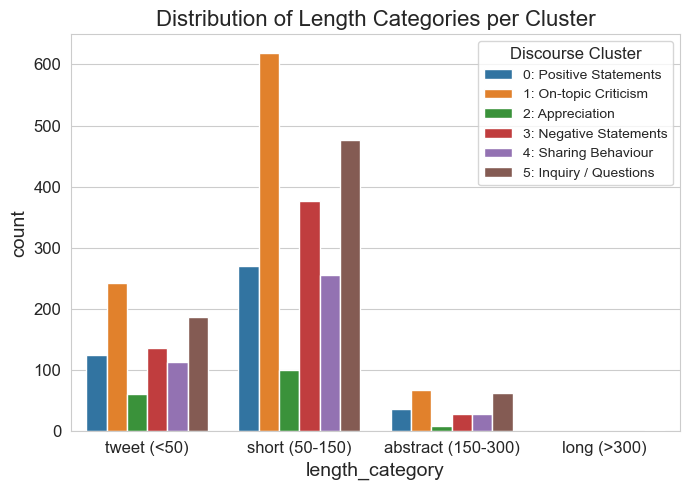

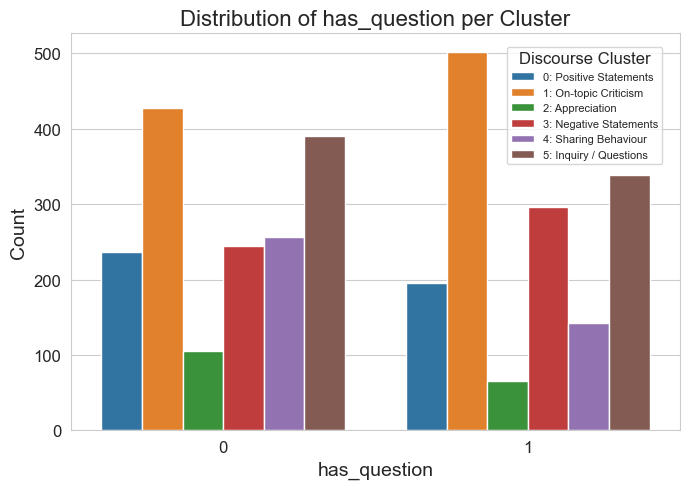

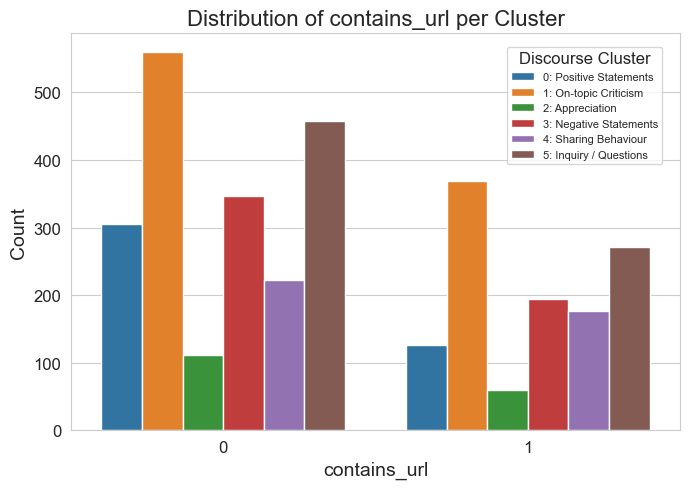

In [164]:
features_kde = ["num_hashtags", "num_unique_words"]   # numeric features → KDE
features_bar = ["has_question", "contains_url"]       # binary features → bar chart

# Cluster name mapping
cluster_names = {
    0: "Positive Statements",
    1: "On-topic Criticism",
    2: "Appreciation",
    3: "Negative Statements",
    4: "Sharing Behaviour",
    5: "Inquiry / Questions"
}

# Build "ID: name" labels for plotting
cluster_labels = {k: f"{k}: {v}" for k, v in cluster_names.items()}

# Add a label column to the dataframe
posts_df["Cluster_Label"] = posts_df["Cluster_KMeans"].map(cluster_labels).astype("category")

# Palette keyed by the label strings
cluster_palette_labeled = {
    cluster_labels[0]: "#1f77b4",
    cluster_labels[1]: "#ff7f0e",
    cluster_labels[2]: "#2ca02c",
    cluster_labels[3]: "#d62728",
    cluster_labels[4]: "#9467bd",
    cluster_labels[5]: "#8c564b",
}

# --- Length Category Plot ---
plt.figure(figsize=(7,5))
sns.countplot(
    data=posts_df,
    x="length_category",
    hue="Cluster_Label",
    palette=cluster_palette_labeled
)
plt.title("Distribution of Length Categories per Cluster", fontsize=16)
plt.xlabel("length_category", fontsize=14)
plt.ylabel("count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Discourse Cluster", title_fontsize=12, fontsize=10)
plt.tight_layout()
plt.show()

# --- Bar charts for binary features ---
for feature in features_bar:
    plt.figure(figsize=(7,5))
    sns.countplot(
        data=posts_df,
        x=feature,
        hue="Cluster_Label",
        palette=cluster_palette_labeled
    )
    plt.title(f"Distribution of {feature} per Cluster", fontsize=16)
    plt.xlabel(feature, fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # LEGEND INSIDE, BUT NOT OVERLAPPING BARS
    plt.legend(
        title="Discourse Cluster",
        title_fontsize=12,
        fontsize=8,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98)   # shift the legend slightly away from data
    )

    plt.tight_layout()
    plt.show()






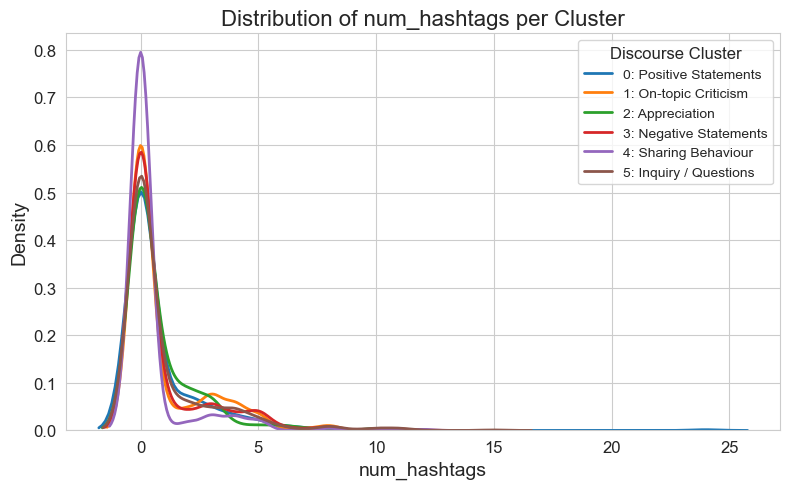

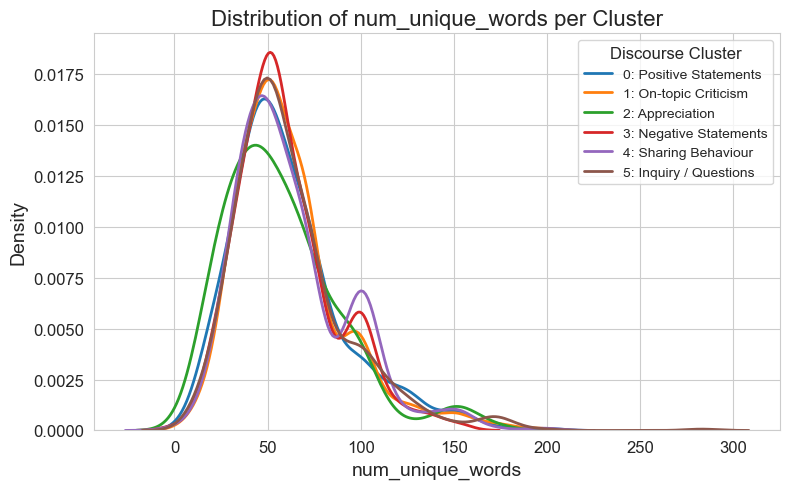

In [150]:
features_kde = ["num_hashtags", "num_unique_words"]   # numeric features → KDE
features_bar = ["has_question", "contains_url"]       # binary features → bar chart

# Cluster name mapping
cluster_names = {
    0: "Positive Statements",
    1: "On-topic Criticism",
    2: "Appreciation",
    3: "Negative Statements",
    4: "Sharing Behaviour",
    5: "Inquiry / Questions"
}

cluster_palette = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c",
    3: "#d62728",
    4: "#9467bd",
    5: "#8c564b",
}

# --- KDE plots for numeric features (manual loop, explicit labels) ---
unique_clusters = sorted(posts_df["Cluster_KMeans"].unique())

for feature in features_kde:
    plt.figure(figsize=(8,5))

    for c in unique_clusters:
        subset = posts_df[posts_df["Cluster_KMeans"] == c]

        sns.kdeplot(
            x=subset[feature],
            label=f"{c}: {cluster_names.get(c, f'Cluster {c}')}",
            color=cluster_palette.get(c, "#000000"),
            common_norm=False,
            fill=False,
            linewidth=2,
        )

    plt.title(f"Distribution of {feature} per Cluster", fontsize=16)
    plt.xlabel(feature, fontsize=14)
    plt.ylabel("Density", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Discourse Cluster", title_fontsize=12, fontsize=10)
    plt.tight_layout()
    plt.show()


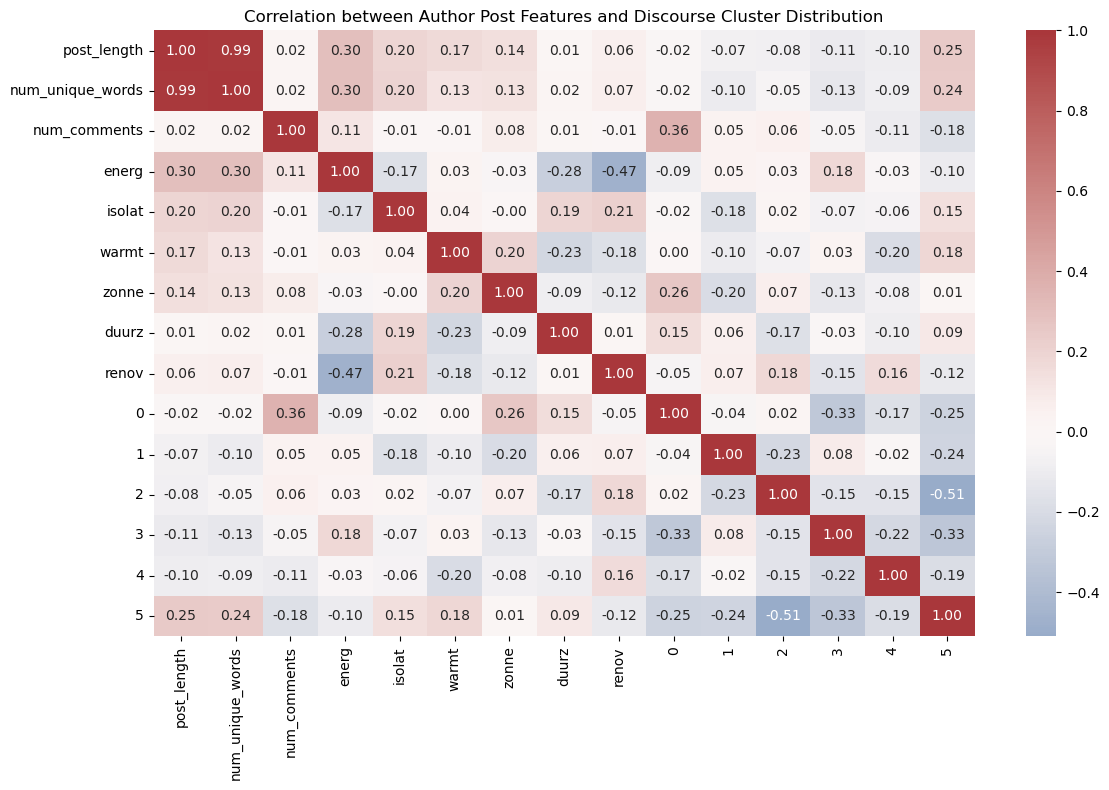

In [120]:
import pandas as pd

# Group comments by author and cluster
author_cluster_dist = (
    posts_df.groupby(['author_name', 'Cluster_KMeans'])
      .size()
      .reset_index(name='Comment_Count')
)

# Normalize to get proportions of each cluster within each author
author_cluster_dist['Proportion'] = (
    author_cluster_dist['Comment_Count'] /
    author_cluster_dist.groupby('author_name')['Comment_Count'].transform('sum')
)

# Pivot → each row = author, each column = cluster proportion
author_cluster_matrix = (
    author_cluster_dist
    .pivot(index='author_name', columns='Cluster_KMeans', values='Proportion')
    .fillna(0)
)
author_features = (
    posts_df.groupby('author_name')[[
        'post_length', 'num_unique_words', 'num_comments',
        'energ', 'isolat', 'warmt', 'zonne', 'duurz', 'renov'
    ]]
    .mean()
    .reset_index()
)
# Combine author-level discourse (from comments) with post features (from posts)
author_summary = author_features.merge(
    author_cluster_matrix,
    on='author_name',
    how='left'
)
corr = author_summary.drop(columns=['author_name']).corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt=".2f")
plt.title('Correlation between Author Post Features and Discourse Cluster Distribution')
plt.tight_layout()
plt.show()


In [121]:
author_summary

,author_name,post_length,num_unique_words,num_comments,energ,isolat,warmt,zonne,duurz,renov,0,1,2,3,4,5
0,Acantus,81.730769,60.500000,17.923077,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.269231,0.153846,0.269231,0.230769,0.038462,0.038462
1,Accolade,85.860215,62.956989,9.000000,0.688172,0.182796,0.032258,0.602151,0.440860,0.000000,0.193548,0.064516,0.236559,0.215054,0.021505,0.268817
2,Actium,80.462264,61.000000,6.547170,0.754717,0.056604,0.000000,0.179245,0.613208,0.141509,0.056604,0.141509,0.160377,0.320755,0.028302,0.292453
3,Alwel,50.488889,41.688889,4.555556,0.244444,0.000000,0.111111,0.222222,0.600000,0.044444,0.133333,0.066667,0.200000,0.200000,0.022222,0.377778
4,Antares,56.347826,47.217391,10.217391,0.043478,0.043478,0.000000,0.043478,1.000000,0.652174,0.086957,0.173913,0.260870,0.434783,0.000000,0.043478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,Zaam Wonen,63.666667,45.666667,1.666667,0.666667,0.000000,0.666667,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.666667
88,Zeeuwland,85.444444,65.488889,11.800000,0.911111,0.000000,0.000000,0.555556,0.000000,0.000000,0.311111,0.000000,0.266667,0.088889,0.066667,0.266667
89,de Alliantie,65.839506,54.182099,12.722222,0.305556,0.070988,0.043210,0.154321,0.743827,0.049383,0.061728,0.203704,0.197531,0.299383,0.058642,0.179012
90,deltaWonen,107.307692,78.384615,3.461538,0.884615,0.000000,0.115385,0.115385,0.807692,0.153846,0.038462,0.153846,0.153846,0.230769,0.038462,0.384615


In [140]:
# 1) per-post cluster proportions from df (comments)
post_cluster_wide = (
    df.groupby('Post')['Cluster_KMeans']
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)
post_cluster_wide.columns = [f'Clusters_{int(c)}' for c in post_cluster_wide.columns]

# 2) merge to post features (which include author_name)
post_level = posts_df.merge(post_cluster_wide, left_on='Post', right_index=True, how='left').fillna(0)


In [141]:
post_level

,Post,Comment,Comments_time,Sentiment over comment from models,final_label_three_models_final,GRO_NLP_prob_Appreciation,GRO_NLP_prob_Criticism,GRO_NLP_prob_Inquiry,GRO_NLP_prob_Statement,roberta_prob_Appreciation,...,num_comments_y,num_comments,author_name,Author_Discourse_Type,Clusters_0,Clusters_1,Clusters_2,Clusters_3,Clusters_4,Clusters_5
0,de zonnepanelen op het dak van ons kantoor doe...,hoeveel KWh hebben de zonnepanelen op de wezen...,2019-04-02T22:14:59,-1,Inquiry,0.010445,0.011370,0.968024,0.010161,0.010267,...,1,1,WormerWonen,1.0,0.00,0.0,0.00,0.0,0.0,1.0
1,in acti-um | onze vakmannen vervangen bij iede...,Dan kom ik langs voor sleutels en krijg er gra...,2018-12-21T15:37:26,0,Criticism,0.027336,0.024728,0.752228,0.195707,0.014287,...,2,2,Actium,1.0,0.00,0.5,0.50,0.0,0.0,0.0
2,in acti-um | onze vakmannen vervangen bij iede...,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",2018-12-21T10:57:48,-1,Statement,0.013757,0.042974,0.139054,0.804214,0.009658,...,2,2,Actium,1.0,0.00,0.5,0.50,0.0,0.0,0.0
3,een hoog energieverbruik is slecht voor het mi...,Het zou beter zijn als Samenwerking een aantal...,2018-08-01T15:22:31,-1,Statement,0.011030,0.014280,0.021973,0.952717,0.009435,...,2,2,0,0.0,0.00,0.5,0.50,0.0,0.0,0.0
4,een hoog energieverbruik is slecht voor het mi...,Leuk als je in een woning woont met warmtepomp...,2018-07-31T11:51:36,0,Criticism,0.047389,0.200883,0.034253,0.717475,0.009971,...,2,2,0,0.0,0.00,0.5,0.50,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,vorige week zijn de laatste huizen van 't getf...,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,2019-07-30T10:57:55,0,Statement,0.040425,0.046785,0.503709,0.409080,0.010718,...,3,3,De Woonplaats,0.0,0.00,0.0,1.00,0.0,0.0,0.0
3193,op de 1e verdieping van het oude schoolgebouw ...,Is er genoeg ventilatie en / of kunnen ramen g...,2020-10-22T12:40:07,0,Inquiry,0.010553,0.010469,0.968225,0.010752,0.010153,...,4,4,Woongoed Zeist,1.0,0.25,0.0,0.25,0.0,0.0,0.5
3194,op de 1e verdieping van het oude schoolgebouw ...,<PERSON> kan je dus straks gebruik van maken. ...,2020-10-21T15:54:40,0,Forward,0.026950,0.707743,0.056919,0.208388,0.014766,...,4,4,Woongoed Zeist,1.0,0.25,0.0,0.25,0.0,0.0,0.5
3195,op de 1e verdieping van het oude schoolgebouw ...,Komen er nog meer werkplekken bij? Of blijft h...,2020-10-19T10:14:18,-1,Inquiry,0.011488,0.011212,0.966778,0.010522,0.009458,...,4,4,Woongoed Zeist,1.0,0.25,0.0,0.25,0.0,0.0,0.5


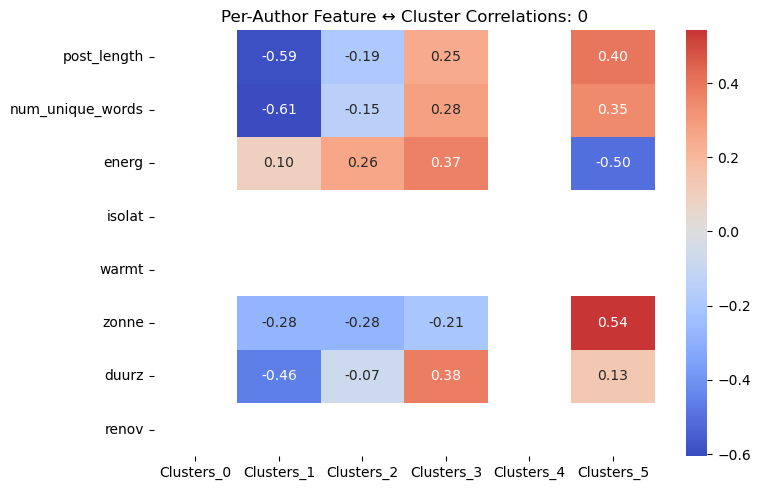

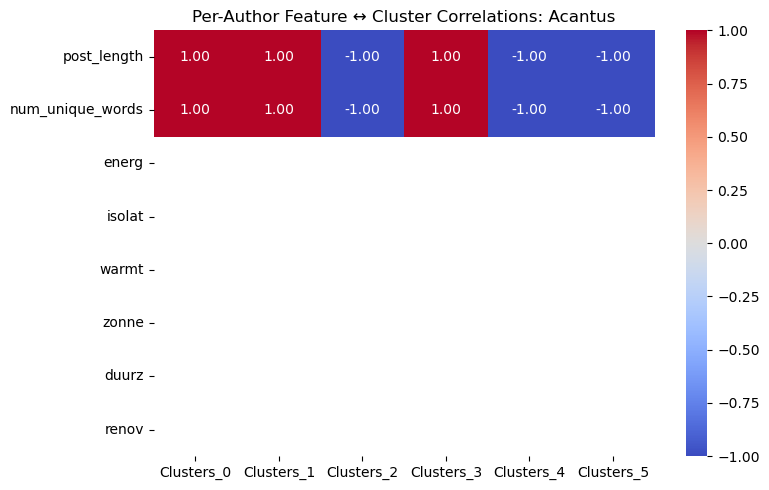

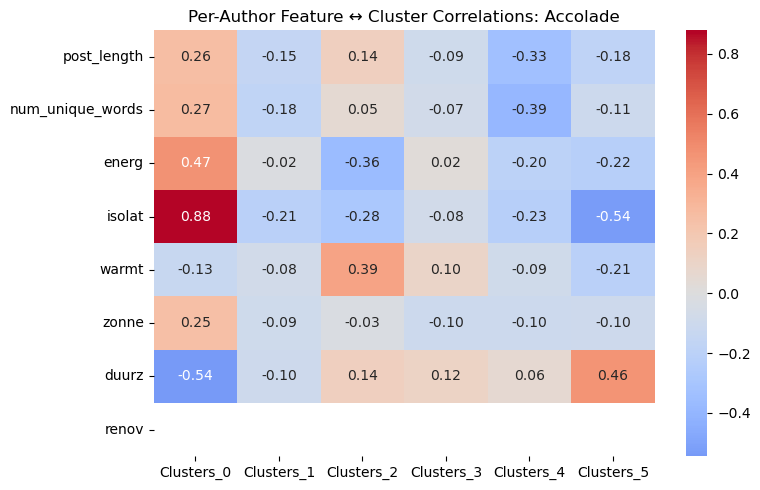

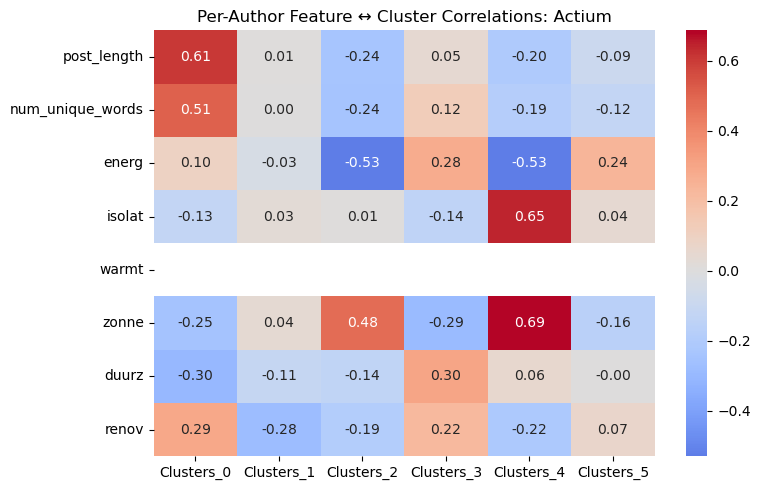

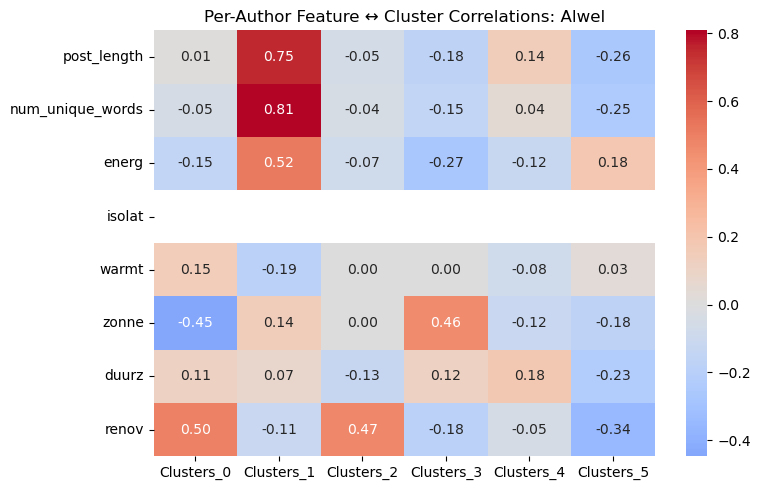

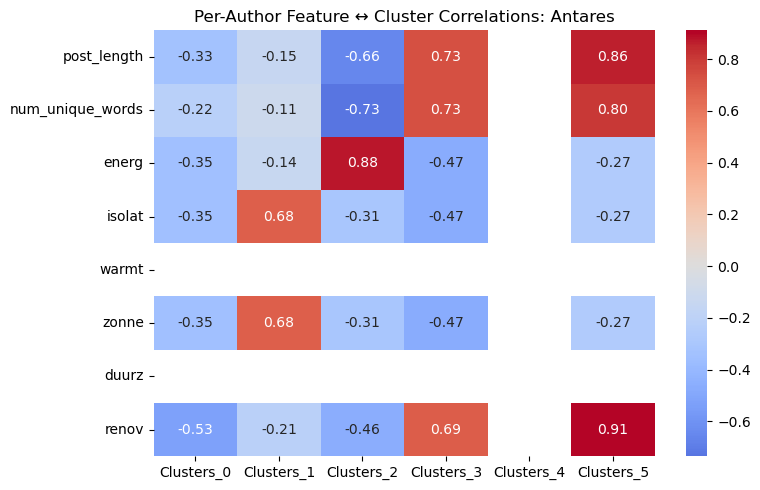

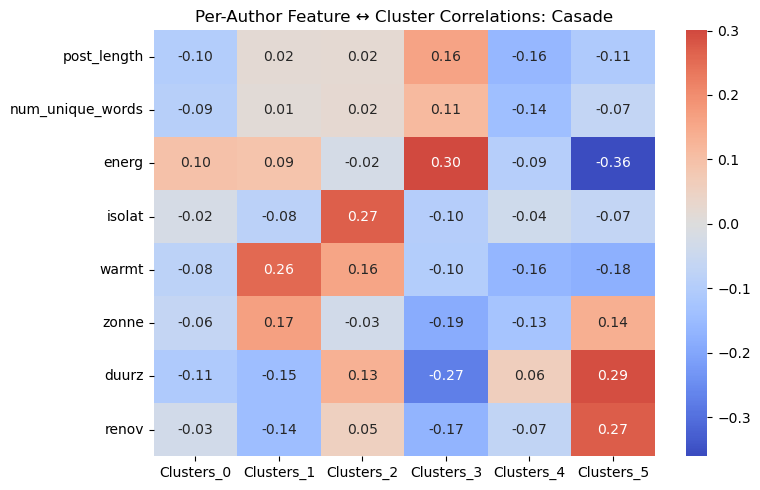

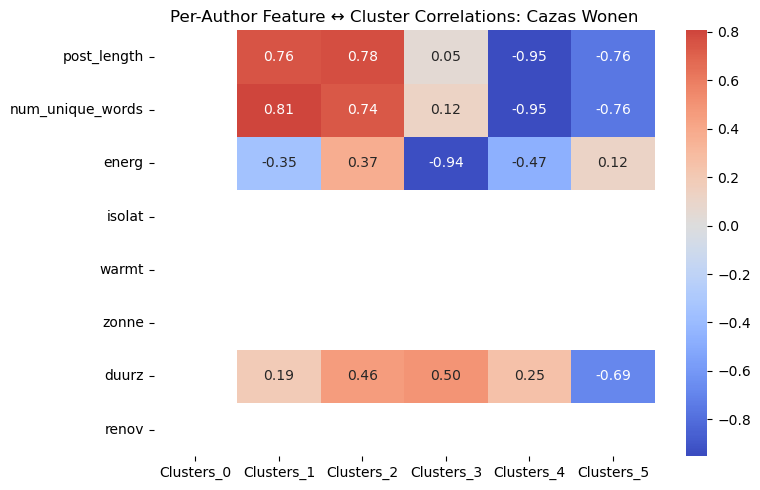

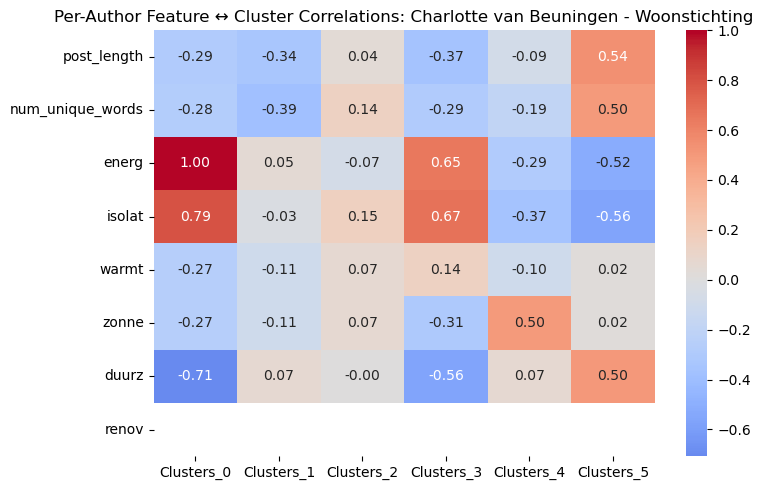

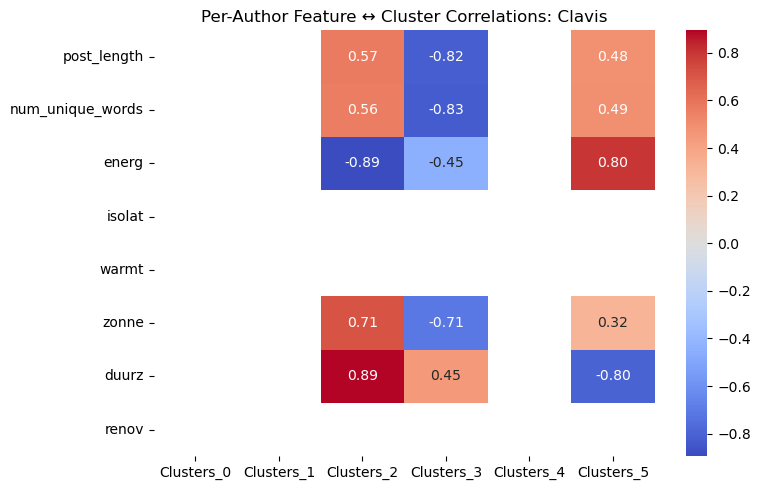

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = ['post_length','num_unique_words','energ','isolat','warmt','zonne','duurz','renov']
cluster_cols = [c for c in post_level.columns if c.startswith('Clusters_')]
# print 10 per-author heatmaps
for author, sub in list(post_level.groupby('author_name'))[:10]:
    if len(sub) < 6:  # need some posts to be meaningful
        continue
    corr = sub[feature_cols + cluster_cols].corr().loc[feature_cols, cluster_cols]
    plt.figure(figsize=(8,5))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
    plt.title(f'Per-Author Feature ↔ Cluster Correlations: {author}')
    plt.tight_layout(); plt.show()


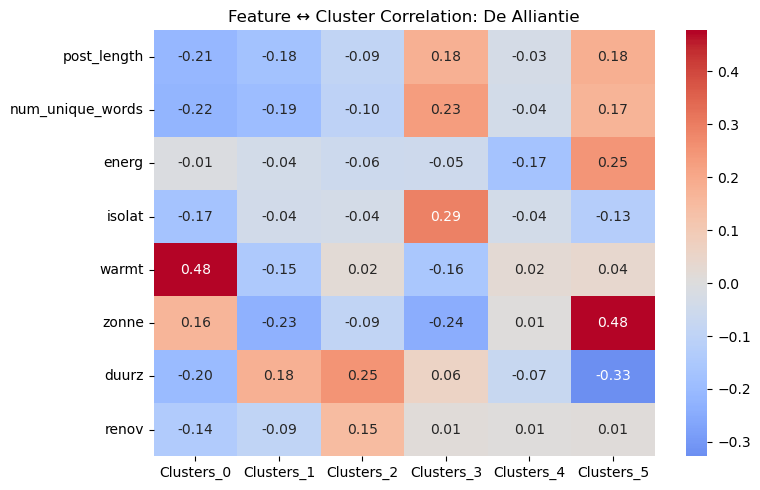

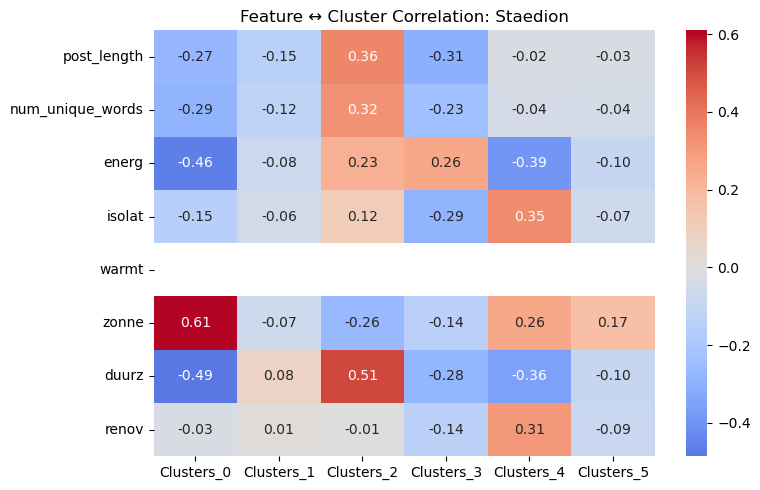

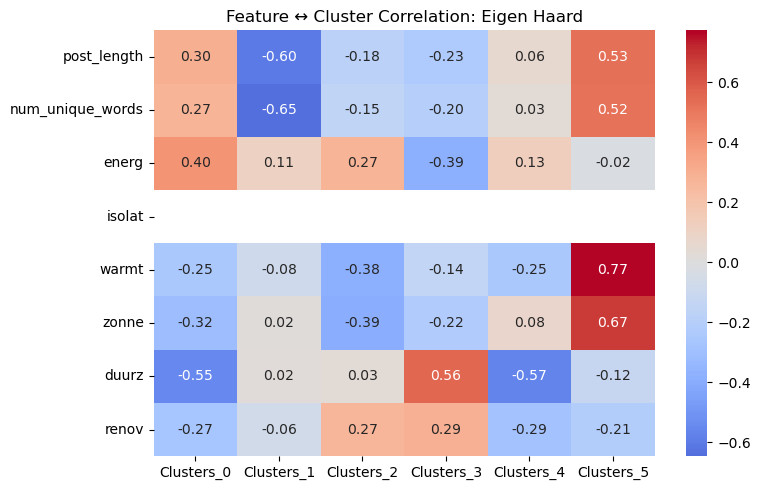

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- authors you want to visualize ---
target_authors = ['de alliantie', 'staedion', 'eigen haard']

# clean + lowercase for matching
post_level['author_name_clean'] = post_level['author_name'].astype(str).str.lower()

# your feature + cluster columns
feature_cols = ['post_length','num_unique_words','energ','isolat','warmt','zonne','duurz','renov']
cluster_cols = [c for c in post_level.columns if c.startswith('Clusters_')]

# loop through each selected author
for author in target_authors:
    sub = post_level[post_level['author_name_clean'] == author]

    if len(sub) < 3:
        print(f"Not enough posts for: {author}")
        continue

    # correlation matrix
    corr = sub[feature_cols + cluster_cols].corr()

    # select feature-to-cluster block
    corr_block = corr.loc[feature_cols, cluster_cols]

    # plot heatmap
    plt.figure(figsize=(8,5))
    sns.heatmap(corr_block, cmap='coolwarm', center=0, annot=True, fmt='.2f')
    plt.title(f"Feature ↔ Cluster Correlation: {author.title()}")
    plt.tight_layout()
    plt.show()


# Multinmial Logistic regression: Posts features and clusters

In [3]:
# posts features to be created: length, number of comments, topics covered,  nu_words

import pandas as pd
df = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Clustering\Probabilties\Clustered_Comments_Probabilities_KMeans.csv")
posts_df =df.copy()
#number pf comments per post
comments_per_post = posts_df.groupby('Post').size().reset_index(name='num_comments')


# post length
posts_df['post_length'] = posts_df['Post'].apply(lambda x: len(str(x).split()))
# number of unique words in posts
posts_df['num_unique_words'] = posts_df['Post'].apply(lambda x: len(set(str(x).split())))

sustainability_keywords = ["energ", "isolat", "warmt", "zonne", "duurz", "renov"]


# Ensure 'post' column is lowercase and handles missing values
posts_df['Post'] = posts_df['Post'].fillna('')

# Create a binary column for each keyword
for kw in sustainability_keywords:
    posts_df[kw] = posts_df['Post'].apply(lambda x: int(kw in x))

# merge author name from df2 on Post

df2 = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\Research Paper\Data\final_data_cleaned_with_author_names.csv")
df2 = df2[['text_ha', 'author_name']]

# Make sure both columns are lowercase strings
posts_df['Post'] = posts_df['Post'].astype(str).str.lower()
df2['text_ha'] = df2['text_ha'].astype(str).str.lower()

# Drop duplicates in df2 to prevent row duplication
df2_unique = df2.drop_duplicates(subset='text_ha')

# Merge only author_name into posts_df (row count will stay the same)
posts_df = posts_df.merge(
    df2_unique[['text_ha', 'author_name']],
    left_on='Post',
    right_on='text_ha',
    how='left'
)

# Remove the helper key column
posts_df.drop(columns=['text_ha'], inplace=True)


In [6]:
posts_df.columns

Index(['Post', 'Comment', 'Comments_time',
       'Sentiment over comment from models', 'final_label_three_models_final',
       'GRO_NLP_prob_Appreciation', 'GRO_NLP_prob_Criticism',
       'GRO_NLP_prob_Inquiry', 'GRO_NLP_prob_Statement',
       'roberta_prob_Appreciation', 'roberta_prob_Criticism',
       'roberta_prob_Inquiry', 'roberta_prob_Statement',
       'debertaV3_prob_Appreciation', 'debertaV3_prob_Criticism',
       'debertaV3_prob_Inquiry', 'debertaV3_prob_Statement', 'Similarity',
       'Similarity_Category', 'avg_prob_Appreciation', 'avg_prob_Criticism',
       'avg_prob_Inquiry', 'avg_prob_Statement', 'avg_prob_Forward',
       'Cluster_KMeans', 'PC1', 'PC2', 'num_comments_x', 'post_length',
       'num_unique_words', 'energ', 'isolat', 'warmt', 'zonne', 'duurz',
       'renov', 'num_comments_y', 'num_comments', 'author_name'],
      dtype='object')

In [9]:
# If needed:
# pip install statsmodels pandas numpy scikit-learn

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
# --- 1.1: Outcome and predictors ---
feature_cols = ['post_length',
       'num_unique_words', 'energ', 'isolat', 'warmt', 'zonne', 'duurz',
       'renov'] 
y = posts_df["Cluster_KMeans"]            # clusters 1–5
X_raw = posts_df[feature_cols]     # original features



# --- 1.2: (Optional but recommended) standardize continuous features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)

# --- 1.3: Add intercept ---
X = sm.add_constant(X)       # adds a column "const"

# MNLogit expects a 1D array-like for y
model = sm.MNLogit(y, X)
result = model.fit(method="newton", maxiter=100, full_output=True, disp=False)

# print(result.summary())

# coef = result.params
# print(coef)




                          MNLogit Regression Results                          
Dep. Variable:         Cluster_KMeans   No. Observations:                 3197
Model:                        MNLogit   Df Residuals:                     3152
Method:                           MLE   Df Model:                           40
Date:                Thu, 20 Nov 2025   Pseudo R-squ.:                 0.01659
Time:                        14:15:46   Log-Likelihood:                -5328.3
converged:                       True   LL-Null:                       -5418.2
Covariance Type:            nonrobust   LLR p-value:                 1.250e-19
Cluster_KMeans=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0554      0.076      0.732      0.464      -0.093       0.204
post_length         -0.4333      0.417     -1.039      0.299      -1.251       0.384
num_unique_words     0.2741 

In [10]:
# odds_ratios = np.exp(coef)
# print(odds_ratios)
mfx = result.get_margeff(at="overall")  # average marginal effects over sample
print(mfx.summary())

                         0         1         2         3         4
const             1.057012  2.241770  1.976918  0.461536  2.028276
post_length       0.648388  0.511685  0.379752  0.499826  0.556379
num_unique_words  1.315353  1.782061  2.667129  1.808269  1.776856
energ             1.100467  1.125144  1.095246  0.738317  1.085808
isolat            0.922111  1.015601  1.005672  0.918737  0.945502
warmt             0.837785  0.829236  0.809419  0.618445  0.844469
zonne             0.666643  0.742257  0.680844  0.744091  0.765091
duurz             1.155319  1.125004  1.107259  0.846321  1.112217
renov             1.019448  1.070053  1.099024  1.201940  0.967248
       MNLogit Marginal Effects      
Dep. Variable:         Cluster_KMeans
Method:                          dydx
At:                           overall
Cluster_KMeans=0      dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
post_len

🚀 PART 1 — High-Level Summary (best for your paper)

Post characteristics strongly shape the kinds of comments they receive.
Longer posts and richer vocabulary tend to produce more neutral statements or more harsh criticism, depending on the feature.
Topic indicators such as solar, warmth, and sustainability significantly shift comments from inquiries toward statements or criticism, while energy and renovation topics influence the balance between appreciation and other discourse types.

Now I break down each variable.

🚀 PART 2 — Variable-by-variable interpretation

(in terms of semantic cluster meanings)

1️⃣ post_length
Significant ME effects:

C0 (Statement & Forward) +7.2 pp

Weak trend: C3 (Harsh Criticism) –7.8 pp

Interpretation (human language):

Longer posts generate more neutral or slightly off-topic statements (C0), likely because readers react more informationally.
There is weak evidence that longer posts discourage harsh criticism (C3).

Narrative:
Long posts → more neutral commentary, less aggressive commentary.

2️⃣ num_unique_words

(richness / expressiveness / lexical variety)

Significant effects:

C0 (Statement/Forward): –6.6 pp

C3 (Harsh Criticism): +9.2 pp

Interpretation:

Posts with richer vocabulary attract more harsh criticism, possibly because sophisticated or technical language triggers stronger or more polarized reactions.
Meanwhile, such posts receive fewer neutral/off-topic statements (C0).

Narrative:
Richer language → more harsh criticism, fewer neutral “meh” statements.

3️⃣ energ

(posts about energy)

Significant effect:

C4 (Appreciation): –2.1 pp

Interpretation:

Energy-related posts reduce appreciative comments.
Readers are less likely to respond positively to energy-themed content.

4️⃣ isolat

(insulation)

No significant effects.
Interpretation:

Insulation content does not systematically influence comment types.

5️⃣ warmt

(warmth / heating / comfort topic)

Significant effects:

C0 (Statement & Forward): +2.1 pp

C4 (Appreciation): –1.7 pp

Interpretation:

Warmth-related posts draw more neutral/forwarding statements and fewer appreciative comments.
These posts do not spark positivity — responses tend to be flat, neutral, or routine.

6️⃣ zonne

(solar)

Significant effects:

C0 (Statement & Forward): +3.4 pp

C1 (Criticism/Statement): –1.4 pp

C3 (Harsh Criticism): –2.1 pp

Interpretation:

Solar posts prompt more neutral or off-topic statements, and less criticism altogether (both mild and harsh).
These posts are not polarizing; people respond neutrally rather than critically.

Narrative:
Solar topics → fewer negative comments, more neutral reactions.

7️⃣ duurz

(sustainability)

Significant effects:

C4 (Appreciation): –1.4 pp

Interpretation:

Sustainability posts reduce the likelihood of positive/appreciative comments.
They do not generate negativity per se, but they don’t attract praise either.

8️⃣ renov

(renovation)

Significant effects:

C4 (Appreciation): +0.8 pp

C5 (Inquiry): –1.7 pp

Interpretation:

Renovation posts attract more appreciation and fewer questions.
Readers tend to approve these posts rather than seek clarification.

🚀 PART 3 — Clean Academic Interpretation (ready for your paper)

Here is a polished text you can paste directly:

Interpretation of Marginal Effects by Semantic Cluster

Post characteristics exert systematic influences on the types of comments they receive. Longer posts significantly increase the probability of neutral or off-topic statements (C0) by 7.2 percentage points, while weakly lowering the likelihood of harsh criticism (C3). Posts with richer vocabulary produce a marked shift from neutral comments (–6.6 pp for C0) toward harsh criticism (+9.2 pp for C3), indicating that lexical complexity may activate more polarized responses.

Topical indicators also matter. Energy and sustainability topics significantly reduce appreciation (C4), whereas renovation increases appreciation (+0.8 pp) and reduces inquiries (C5). Warmth and solar topics increase neutral/forwarding statements (C0) and reduce positive (C4) or critical (C1/C3) responses. Solar posts in particular elicit fewer critical or harsh reactions, suggesting that they are perceived as less contentious or more routine.

Overall, the results show that both linguistic richness and topical framing shape the emotional and discursive patterns of reader responses, shifting comment distributions across neutral, critical, appreciative, and inquiry-oriented categories.

In [13]:
posts_df["author_name"].unique()

array(['WormerWonen', 'Actium', nan, 'Accolade', 'Woonforte', 'Staedion',
       'Woonstad Rotterdam', 'de Alliantie', 'Zeeuwland', 'Cazas Wonen',
       'Woonstichting Centrada', 'ProWonen', 'Woningcorporatie Rhiant',
       'Servatius Wonen & Vastgoed', 'De Goede Woning Zoetermeer',
       'Antares', 'Lefier', 'Eigen Haard', 'Sité Woondiensten', 'Casade',
       'Alwel', 'WoonFriesland', 'Woningcorporatie Mooiland',
       'SallandWonen Woningstichting', 'Woonzorg Nederland',
       'Charlotte van Beuningen - Woonstichting', 'Goed Wonen Gemert',
       'Omnia Wonen', 'Poort6', 'Woonservice', 'Rijnhart Wonen',
       'Oost Flevoland Woondiensten', 'De Woonschakel', 'Clavis',
       'Havensteder', 'Kennemer Wonen', 'MeerWonen',
       'Dynhus: Thuis voor jou', 'Woonstichting SSW', 'Mercatus wonen',
       'De Bouwvereniging', 'Woningstichting Putten', 'Leystromen',
       'Stek', 'Dunavie', 'Woningstichting Barneveld', 'Elkien',
       'deltaWonen', 'Woonveste', 'Plavei', 'Groninger Hu